In [6]:
# Machine Learning Pipeline
# CSV File
#       │
#       ▼
# Load Dataset
#       │
#       ▼
# Create Copy Dataset
#       │
#       ▼
# Data Preprocessing
#       │
#       ├── Missing Values
#       ├── Duplicate Records
#       └── Remove Student_ID
#       │
#       ▼
# Encoding
# (Text → Number)
#       │
#       ▼
# Feature Selection
# (X and y)
#       │
#       ▼
# Train/Test Split
# (80% Train, 20% Test)
#       │
#       ▼
# Feature Scaling
# (StandardScaler)
#       │
#       ▼
# Ready for Machine Learning Model

In [2]:
# Step 1 : Import Libraries
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

Saving student_burnout_dropout_dataset_2 (1).csv to student_burnout_dropout_dataset_2 (1).csv


In [7]:
# Step 2 : Load Dataset
df = pd.read_csv("/content/student_burnout_dropout_dataset_2 (1).csv")

In [8]:
df.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


In [9]:
# Step 3 : Create Copy Dataset  (Industry Standard)
df_copy = df.copy()

In [10]:
df_copy.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


In [11]:
# Step 4 : Data Preprocessing


In [12]:
# Fill Numerical Missing Values
# fill missing values in numerical columns using the median value.
num_cols = df_copy.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df_copy[col] = df_copy[col].fillna(df_copy[col].median())

In [13]:
df_copy.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,0
Study_Hours_Per_Day,0
Previous_GPA,0
Backlogs,0


In [14]:
# Fill Categorical Missing Values
# Fill missing values in categorical columns using the mode (the most common value).
cat_cols = df_copy.select_dtypes(include="object").columns

for col in cat_cols:
    df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])

In [18]:
df_copy.isnull().sum()

,0
Age,0
Gender,0
Year_of_Study,0
Department,0
Residence_Type,0
Attendance_Percent,0
Study_Hours_Per_Day,0
Previous_GPA,0
Backlogs,0
Sleep_Hours,0


In [17]:
# Duplicate Check
df_copy.duplicated().sum()

np.int64(0)

In [16]:
# Remove duplicates
df_copy.drop_duplicates(inplace=True)

In [15]:
# Remove Unnecessary Column
df_copy.drop("Student_ID",axis=1,inplace=True)

In [19]:
# Step 5 : Encoding
# Machine learning models do not understand textual data directly.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [20]:
# Find Text Columns
cat_cols = df_copy.select_dtypes(include="object").columns

print(cat_cols)

Index(['Gender', 'Department', 'Residence_Type', 'Part_Time_Job',
       'Family_Income_Bracket', 'Counseling_Access', 'Burnout_Level',
       'Dropout_Risk'],
      dtype='object')


In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_copy[col] = le.fit_transform(df_copy[col])

In [22]:
df_copy.head()

,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,23,0,2,5,1,93.0,4.1,7.13,2.0,6.2,...,4,5.5,10.0,4.0,5.1,7.0,4.5,0,1,0
1,20,0,4,2,0,94.3,0.0,10.00,0.0,6.3,...,1,3.7,4.0,5.5,5.1,9.3,2.8,1,2,1
2,24,1,2,1,2,61.2,2.6,8.02,0.0,4.2,...,3,4.8,8.1,9.0,5.2,5.7,5.4,0,0,1
3,21,0,4,4,1,66.9,3.1,5.34,1.0,5.7,...,2,7.0,6.6,2.8,4.2,5.1,3.9,0,0,1
4,23,0,1,2,1,84.8,2.9,4.45,1.0,8.0,...,2,1.3,7.3,0.9,6.4,8.1,5.1,0,1,0


In [23]:
# # Feature Selection
# # x= input_feature y=Target_Feature
# # We want to predict the Dropout_Risk column, so we remove it from the feature set (X).
# X = df_copy.drop("Dropout_Risk",axis=1)

# y = df_copy["Dropout_Risk"]

In [24]:
X = df_copy[[
    "Age",
    "Gender",
    "Year_of_Study",
    "Attendance_Percent",
    "Study_Hours_Per_Day",
    "Previous_GPA",
    "Backlogs",
    "Financial_Stress_Score",
    "Stress_Level",
    "Burnout_Level"
]]

y = df_copy["Dropout_Risk"]

In [25]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# df_copy["Dropout_Risk"] = le.fit_transform(df_copy["Dropout_Risk"])

# print(le.classes_)

In [26]:
print(X.shape)

print(y.shape)

(800, 10)
(800,)


In [27]:
# # Step 7 : Train Test Split
# # Until now, the entire dataset was used as a single dataset.
#  To train and evaluate the machine learning model,
#  we divide it into two parts: the training set and the testing set.


In [28]:
# Training Data

# Used to teach the model.

# Testing Data

# Used to test the model.

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [30]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(640, 10)
(160, 10)
(640,)
(160,)


In [31]:
# Step 8 : Feature Scaling
# Different features have different value ranges.

# Example:

# Age = 20
# Attendance = 95
# Income = 500000

# The Income value is much larger than the other features.

# Because of this, the machine learning model may give more importance to Income.

# To avoid this problem, we scale all features to a similar range.

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
# Training Data Scaling
X_train = scaler.fit_transform(X_train)

In [34]:
# Testing Data Scaling
X_test = scaler.transform(X_test)

In [35]:
print(X_train)

[[-1.11068249 -0.89344465  1.56031832 ...  0.37331937  0.58988606
  -1.43099812]
 [ 0.43713851  0.84456318  1.56031832 ... -1.23544437 -0.51092881
  -1.43099812]
 [ 0.43713851 -0.89344465 -0.26361542 ...  1.20068358 -0.66818807
  -0.13926498]
 ...
 [-0.33677199  0.84456318  1.56031832 ... -0.13229209  1.00924411
  -1.43099812]
 [-1.11068249  0.84456318 -1.17558229 ...  0.37331937 -0.66818807
  -1.43099812]
 [-0.72372724  0.84456318 -1.17558229 ... -0.59193887  1.48102191
  -1.43099812]]


In [36]:
# If I want to complete the header with proper formatting.
X_train_df = pd.DataFrame(X_train, columns=X.columns)

X_train_df.head()

,Age,Gender,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Financial_Stress_Score,Stress_Level,Burnout_Level
0,-1.110682,-0.893445,1.560318,-0.991039,-2.059104,-0.966697,-0.882256,0.373319,0.589886,-1.430998
1,0.437139,0.844563,1.560318,-2.059319,-1.274372,0.336904,0.185124,-1.235444,-0.510929,-1.430998
2,0.437139,-0.893445,-0.263615,0.882108,-0.031880,0.329621,-0.882256,1.200684,-0.668188,-0.139265
3,1.211049,0.844563,-0.263615,-2.308096,0.818247,-0.100057,0.185124,-2.292632,-1.402065,-0.139265
4,-1.110682,-0.893445,0.648351,1.686976,0.033515,-1.374528,0.185124,1.568401,-1.087546,-1.430998


In [37]:
print(X_test)

[[-1.11068249 -0.89344465  1.56031832 ... -0.91369162 -0.56334856
  -0.13926498]
 [-0.72372724  0.84456318 -1.17558229 ...  0.0975313  -0.72060783
  -0.13926498]
 [ 0.05018326 -0.89344465 -1.17558229 ...  0.37331937  0.32778729
   1.15246816]
 ...
 [ 0.82409376 -0.89344465  0.64835145 ... -0.13229209  0.74714533
   1.15246816]
 [ 1.59800425  2.58257102  0.64835145 ...  0.14349598  0.95682435
   1.15246816]
 [ 0.05018326  0.84456318  0.64835145 ...  0.87893083  0.06568851
  -0.13926498]]


In [38]:
#If I want to complete the header with proper formatting.
X_test_df = pd.DataFrame(X_test, columns=X.columns)

X_test_df.head()

,Age,Gender,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Financial_Stress_Score,Stress_Level,Burnout_Level
0,-1.110682,-0.893445,1.560318,-1.034941,0.098909,0.278643,0.185124,-0.913692,-0.563349,-0.139265
1,-0.723727,0.844563,-1.175582,-2.117855,0.164303,0.009183,-0.882256,0.097531,-0.720608,-0.139265
2,0.050183,-0.893445,-1.175582,1.079666,1.145218,0.103858,0.185124,0.373319,0.327787,1.152468
3,-1.497638,-0.893445,-0.263615,0.201629,1.014430,-0.617128,-0.882256,1.108754,0.222948,-0.139265
4,1.211049,0.844563,-1.175582,-1.525179,1.406796,0.176685,-0.882256,-0.316151,1.376182,-0.139265


\\**End: Successfully prepared for Machine Learning model building. Next step: Apply the Machine Learning algorithm.**

**Apply Logistic Regression Algorithm**

In [39]:
# 1. Import Dataset

# 2. Data Preprocessing

# 3. Encoding

# 4. Feature Selection

# 5. Train Test Split

# 6. Feature Scaling (if required)

# 7. Import Logistic Regression

# 8. Create Model

# 9. Train Model

# 10. Prediction

# 11. Actual vs Predicted

# Model Evaluation


# 12. Accuracy

# 13. Confusion Matrix

# 14. Classification Report


In [40]:
# for balance checking
print(y.value_counts())

Dropout_Risk
1    437
0    363
Name: count, dtype: int64


In [41]:
# Linear Regression
# Logistic Regression
# Decision Tree
# Random Forest
# KNN
# SVM
# Naive Bayes

# Step 1 : Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [42]:
# Step 2 : Create Model
model = LogisticRegression()

In [43]:
# Step 3 : Train Model  (Sabse Important)
# print(y_train.head())
# print(y_train.unique())
model.fit(X_train, y_train)

LogisticRegression()

In [44]:
print("Train Accuracy :", model.score(X_train, y_train))
print("Test Accuracy  :", model.score(X_test, y_test))

Train Accuracy : 0.640625
Test Accuracy  : 0.625


In [45]:
print(y_test)

696    0
667    1
63     0
533    1
66     0
      ..
589    0
798    0
744    1
513    0
670    0
Name: Dropout_Risk, Length: 160, dtype: int64


In [46]:
# Step 4 : Prediction
y_pred = model.predict(X_test)
print(y_pred)

[1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0
 0 1 1 0 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 1 1
 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0
 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0
 0 1 0 1 0 1 1 0 1 1 1 1]


In [47]:
# print(y_pred[:10])

In [48]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       0          1
1       1          1
2       0          0
3       1          1
4       0          1
5       0          1
6       1          1
7       0          1
8       1          1
9       1          1


In [49]:
# Accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy :", accuracy * 100, "%")

Accuracy : 0.625
Accuracy : 62.5 %


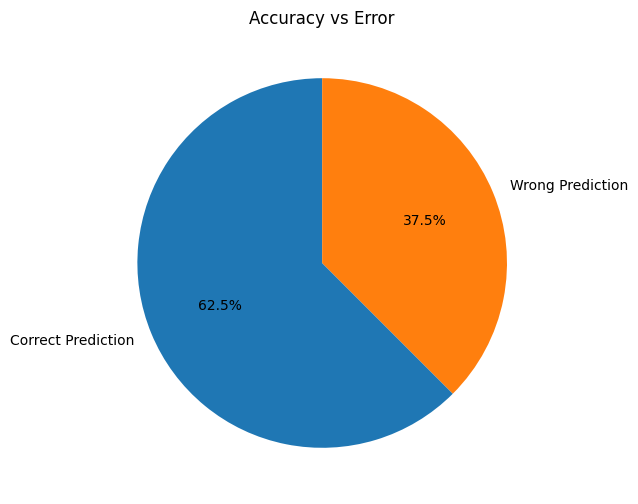

In [50]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred) * 100
error = 100 - accuracy

plt.figure(figsize=(6,6))
plt.pie(
    [accuracy, error],
    labels=["Correct Prediction", "Wrong Prediction"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Accuracy vs Error")
plt.show()

In [51]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37 29]
 [31 63]]


In [52]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.56      0.55        66
           1       0.68      0.67      0.68        94

    accuracy                           0.62       160
   macro avg       0.61      0.62      0.61       160
weighted avg       0.63      0.62      0.63       160



In [53]:
# # Prediction Probability
# probability = model.predict_proba(X_test)

# print(probability[:5])

In [54]:
# #ROC-AUC ScoreROC (Receiver Operating Characteristic)

# y_prob = model.predict_proba(X_test)[:,1]
# from sklearn.metrics import roc_auc_score

# roc_score = roc_auc_score(y_test, y_prob)

# print("ROC-AUC Score :", roc_score)

In [55]:
# New Student Prediction
# 0 no dropout 1 dropout
new_student = X.iloc[[0]]

new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

print(prediction)

[0]


In [56]:
model.predict_proba(new_student)

array([[0.67050147, 0.32949853]])

In [60]:
import joblib

model.fit(X_train, y_train)

# Model save karo
joblib.dump(model, "student_dropout_model.pkl")
print("Model saved successfully as 'student_dropout_model.pkl")

Model saved successfully as 'student_dropout_model.pkl


In [61]:
import gradio as gr
import joblib
import numpy as np

# Load trained model
model = joblib.load("student_dropout_model.pkl")


def predict_dropout(
    age,
    gender,
    year_of_study,
    attendance,
    study_hours,
    previous_gpa,
    backlogs,
    financial_stress,
    stress_level,
    burnout_level
):

    # Encoding
    gender = 1 if gender == "Male" else 0

    # if gender=="Male":
    # gender=1
    # else:
    # gender=0

    burnout_mapping = {
        "Low": 0,
        "Medium": 1,
        "High": 2
    }

    burnout = burnout_mapping[burnout_level]

    input_data = np.array([[
        age,
        gender,
        year_of_study,
        attendance,
        study_hours,
        previous_gpa,
        backlogs,
        financial_stress,
        stress_level,
        burnout
    ]])

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "Student Will Drop Out"
    else:
        return "Student Will Not Drop Out"


student_dropout_app = gr.Interface(
    fn=predict_dropout,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(["Male", "Female"], label="Gender"),
        gr.Dropdown([1, 2, 3, 4], label="Year of Study"),
        gr.Slider(0, 100, label="Attendance Percentage"),
        gr.Number(label="Study Hours Per Day"),
        gr.Number(label="Previous GPA"),
        gr.Number(label="Backlogs"),
        gr.Slider(1, 10, step=1, label="Financial Stress Score"),
        gr.Slider(1, 10, step=1, label="Stress Level"),
        gr.Dropdown(["Low", "Medium", "High"], label="Burnout Level"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Student Dropout Risk Prediction",
    description="Predict whether a student has High or Low Dropout Risk."
)

student_dropout_app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d706d81117f10c8784.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
